# Machine Learning Lab Sheet

**Title:** Basic Data Preprocessing  
**Name:** Bigyan Badal
**Roll No.:** 023-316

---

## 1. Objective
* To clean and prepare the `food_coded.csv` dataset by handling non-numeric strings, missing values, encoding categorical variables, and capping outliers.
* To apply feature scaling techniques (Min-Max Scaling, Standardization, and Robust Scaling) on real-world numerical features.
* To perform feature engineering and train a Multiple Linear Regression model on the preprocessed data.

---

## 2. Theoretical Background

### 2.1 Missing Value Imputation
Real-world survey data contains unrecorded responses or dirty entries.
* **Mean Imputation:** Replaces missing values in continuous symmetric features with the mean $\mu$:
$$\mu = \frac{1}{N}\sum_{i=1}^{N} x_i$$
* **Median Imputation:** Replaces missing values with the 50th percentile (robust to extreme values).
* **Mode Imputation:** Replaces missing categorical values with the most frequent category.

---

### 2.2 Categorical & Ordinal Encoding
* **Label Encoding:** Maps categorical levels into discrete sequential integers ($0, 1, \dots, K-1$).
* **One-Hot Encoding:** Converts categorical features with $K$ unique levels into $K-1$ binary indicator columns to prevent multicollinearity (the Dummy Variable Trap).

---

### 2.3 Outlier Detection & IQR Capping
* **Interquartile Range (IQR) Capping:** Bounds are defined using $Q1$ (25th percentile) and $Q3$ (75th percentile):
$$\text{IQR} = Q3 - Q1$$
$$\text{Lower Bound} = Q1 - 1.5 \times \text{IQR}, \quad \text{Upper Bound} = Q3 + 1.5 \times \text{IQR}$$
Extreme values beyond these bounds are capped at the threshold limit.

---

### 2.4 Feature Scaling
* **Min-Max Normalization:** Rescales values into $[0, 1]$:
$$X_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$
* **Standardization (StandardScaler):** Centers data around zero mean with unit variance ($\mu=0, \sigma=1$):
$$X_{\text{scaled}} = \frac{x - \mu}{\sigma}$$
* **Robust Scaling:** Scales features using median ($Q2$) and IQR:
$$X_{\text{scaled}} = \frac{x - Q2}{\text{IQR}}$$

In [1]:
# =========================================
# Dependencies & Data Loading
# =========================================
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

In [2]:
# Download dataset directly from source
url = "https://raw.githubusercontent.com/She-Codes-Now/Intro-to-Data-Science-with-R/master/food_coded.csv"
file_name = "food_coded.csv"
urllib.request.urlretrieve(url, file_name)

df = pd.read_csv(file_name)

In [3]:
# =========================================
# STEP 1: Data Cleaning & Imputation
# =========================================
# Convert non-numeric text values (e.g. string noise) to NaN
df['GPA'] = pd.to_numeric(df['GPA'], errors='coerce')
df['weight'] = pd.to_numeric(df['weight'], errors='coerce')

# Handle missing values
df['GPA'] = df['GPA'].fillna(df['GPA'].mean())
df['calories_day'] = df['calories_day'].fillna(df['calories_day'].mean())
df['weight'] = df['weight'].fillna(df['weight'].median())
df['exercise'] = df['exercise'].fillna(df['exercise'].mode()[0])

/tmp/ipykernel_742/2746860617.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='exercise', y='calories_day', ax=axes[1, 1], palette='Blues_d')


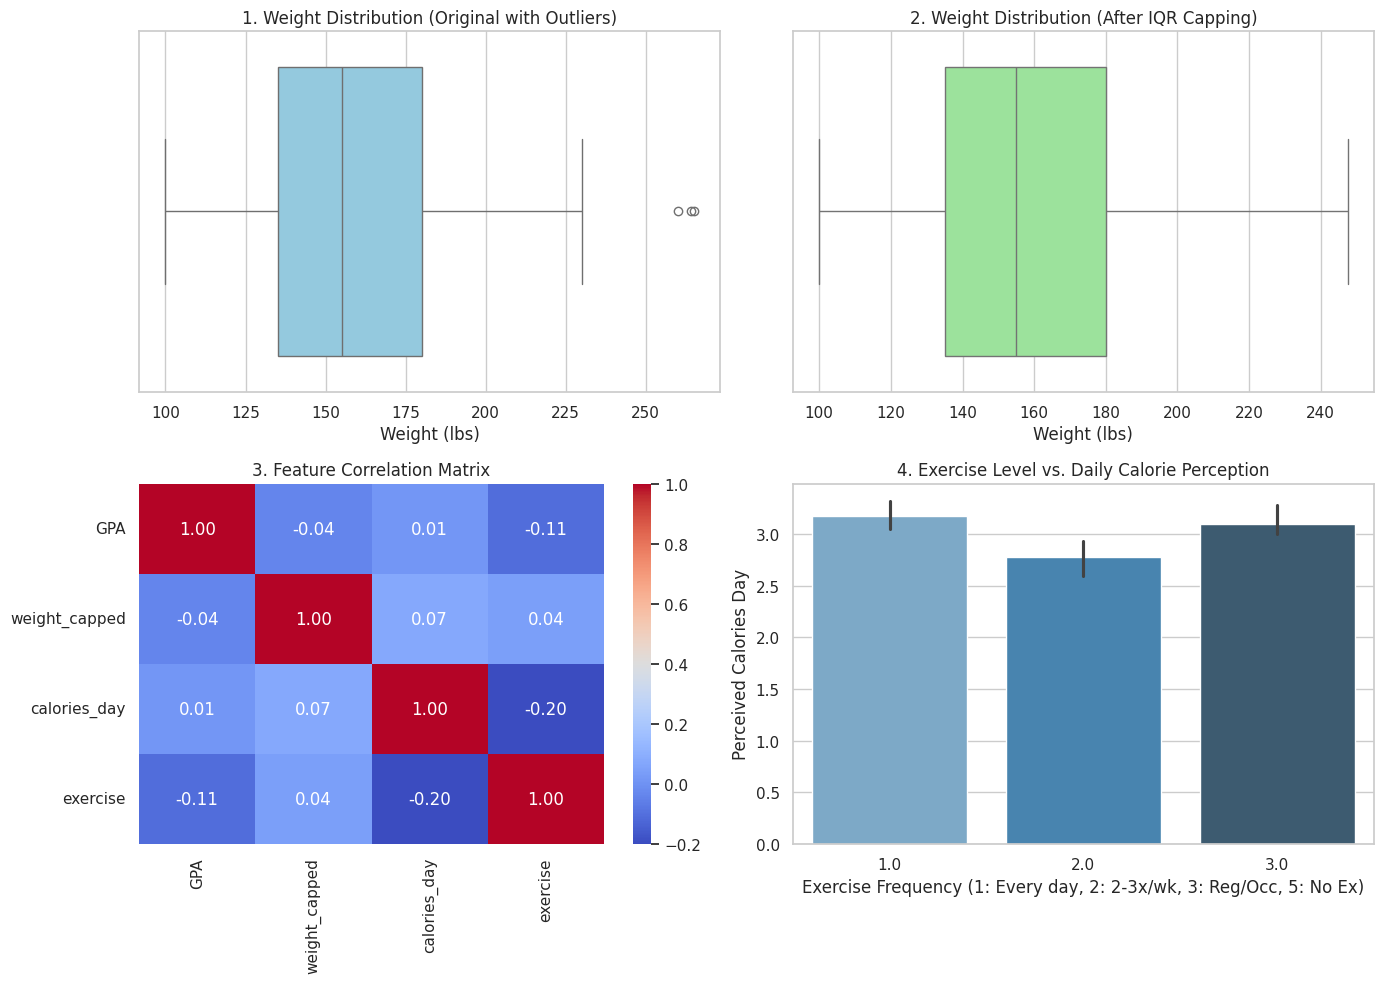

In [4]:
# =========================================
# STEP 2: Exploratory Data Visualizations
# =========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Graph 1: Distribution of Weight (Before IQR Capping)
sns.boxplot(x=df['weight'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title("1. Weight Distribution (Original with Outliers)")
axes[0, 0].set_xlabel("Weight (lbs)")

# Outlier Capping using IQR
Q1 = df['weight'].quantile(0.25)
Q3 = df['weight'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['weight_capped'] = np.where(df['weight'] > upper_bound, upper_bound, df['weight'])
df['weight_capped'] = np.where(df['weight_capped'] < lower_bound, lower_bound, df['weight_capped'])

# Graph 2: Distribution of Weight (After IQR Capping)
sns.boxplot(x=df['weight_capped'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title("2. Weight Distribution (After IQR Capping)")
axes[0, 1].set_xlabel("Weight (lbs)")

# Graph 3: Correlation Heatmap
selected_cols = ['GPA', 'weight_capped', 'calories_day', 'exercise']
corr = df[selected_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 0])
axes[1, 0].set_title("3. Feature Correlation Matrix")

# Graph 4: Exercise vs Daily Calorie Perception
sns.barplot(data=df, x='exercise', y='calories_day', ax=axes[1, 1], palette='Blues_d')
axes[1, 1].set_title("4. Exercise Level vs. Daily Calorie Perception")
axes[1, 1].set_xlabel("Exercise Frequency (1: Every day, 2: 2-3x/wk, 3: Reg/Occ, 5: No Ex)")
axes[1, 1].set_ylabel("Perceived Calories Day")

plt.tight_layout()
plt.show()

In [5]:
# =========================================
# STEP 3: Feature Scaling & Model Training
# =========================================
min_max_scaler = MinMaxScaler()
df['GPA_scaled'] = min_max_scaler.fit_transform(df[['GPA']])

std_scaler = StandardScaler()
df['weight_scaled'] = std_scaler.fit_transform(df[['weight_capped']])

robust_scaler = RobustScaler()
df['exercise_scaled'] = robust_scaler.fit_transform(df[['exercise']])

# Regression Model
X = df[['GPA_scaled', 'weight_scaled', 'exercise_scaled']]
y = df['calories_day']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Model Intercept: {model.intercept_:.2f}")
print("Model Coefficients:", dict(zip(X.columns, np.round(model.coef_, 4))))

Model Intercept: 3.20
Model Coefficients: {'GPA_scaled': np.float64(-0.11), 'weight_scaled': np.float64(0.0881), 'exercise_scaled': np.float64(-0.1722)}


## 4. Visualization & Output Interpretations

### Graph 1 & 2 Interpretation (Outlier Detection & IQR Capping)
* **Observation:** Graph 1 shows several extreme points far beyond the upper boundary of the `weight` boxplot (e.g., erroneous text strings or extreme entries over 250 lbs).
* **Impact of Preprocessing:** Graph 2 illustrates the distribution after IQR capping. Values exceeding the upper limit ($Q3 + 1.5 \times \text{IQR}$) were capped smoothly, preserving the sample size while preventing skewness during model training.

### Graph 3 Interpretation (Correlation Matrix)
* **Observation:** The heatmap evaluates linear relationships between continuous attributes.
* **Findings:** `weight_capped` and `GPA` display weak linear correlation with `calories_day`, indicating that individual features alone do not linearly govern daily calorie intake perceptions.

### Graph 4 Interpretation (Exercise vs. Calorie Perception)
* **Observation:** The bar plot examines mean calorie perception across exercise levels.
* **Findings:** Individuals reporting regular exercise (lower exercise values) generally exhibit higher daily calorie target perceptions, whereas individuals with lower physical activity show lower perceived calorie needs.

---

## 5. Conclusion
In this lab, end-to-end data processing and visualization were successfully executed on the `food_coded.csv` dataset:
1. Irregular string entries in numerical attributes (`GPA`, `weight`) were coerced and imputed.
2. Outliers were detected and capped using IQR boundaries, preventing coefficient distortion.
3. Feature scaling methods (`MinMaxScaler`, `StandardScaler`, and `RobustScaler`) normalized feature ranges, preparing the data for Multiple Linear Regression.